In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **IMPORTING LIBRARY**

In [5]:
#importing library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# **READING THE DATASET**

In [6]:
#redaing the dataset

df = pd.read_csv('../input/digit-recognizer/train.csv')

In [10]:
#first 5 records

df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
#no. of rows and columns

df.shape

(42000, 785)

The data files train.csv contain gray-scale images of hand-drawn digits, from zero through nine.

Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255, inclusive.

The training data set has 785 columns. The first column, called "label", is the digit that was drawn by the user. The rest of the columns contain the pixel-values of the associated image.

In [11]:
#splitting the features and label

x = df.drop(columns=['label'])
y = df['label']

In [12]:
#features

x

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
x.shape

(42000, 784)

In [13]:
#label

y

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [15]:
y.shape

(42000,)

# **FEATURE SELECTION**

In [17]:
# Picking only first 15K data-points to work on for time-effeciency.

y =  y.head(15000)           #labels with 15k data points
x = x.head(15000)       #data with 15k data points
x.shape

(15000, 784)

# **STANDARDIZATION**

In [18]:
# import standard scalar from sklearn

from sklearn.preprocessing import StandardScaler


In [19]:
#model building

ss = StandardScaler()

In [20]:
#fit transform data

ss_x = ss.fit_transform(x)


In [22]:
#print shape of the standardized data

ss_x.shape

(15000, 784)

In [25]:
#final dataset

sample_data = ss_x

# **PCA - PRINCIPAL COMPONENT ANALYSIS**

> Large datasets are increasingly widespread in many disciplines. In order to interpret such datasets, methods are required to drastically reduce their dimensionality in an interpretable way, such that most of the information in the data is preserved. Many techniques have been developed for this purpose, but principal component analysis (PCA) is one of the oldest and most widely used. Its idea is simple—reduce the dimensionality of a dataset, while preserving as much ‘variability’ (i.e. statistical information) as possible.


**PCA is a method that brings together:**
1. A measure of how each variable is associated with one another- (Covariance matrix)

2. The directions in which our data are dispersed- (Eigenvectors)

3. The relative importance of these different directions- (Eigenvalues)

4. PCA combines our predictors and allows us to drop the Eigenvectors that are relatively unimportant

In [26]:
# import decomposition from sklearn

from sklearn import decomposition

**NO. OF FEATURES = 2**

In [27]:
# initializing the pca

pca = decomposition.PCA()

In [28]:
#changing to 2 features (from 784)

pca.n_components = 2

In [32]:
#variance in pca

pca.explained_variance_

array([4.03839784e+01, 2.90374397e+01, 2.71119525e+01, 2.10174088e+01,
       1.80656409e+01, 1.57600109e+01, 1.36864892e+01, 1.27018200e+01,
       1.11151810e+01, 9.97722063e+00, 9.61186466e+00, 8.65069774e+00,
       8.15573292e+00, 7.91395239e+00, 7.54862710e+00, 7.22734563e+00,
       6.77517388e+00, 6.61893402e+00, 6.49002121e+00, 6.30544042e+00,
       6.00412397e+00, 5.69049312e+00, 5.46541444e+00, 5.32205969e+00,
       5.24796115e+00, 4.95787186e+00, 4.91052645e+00, 4.81898017e+00,
       4.60277022e+00, 4.48980799e+00, 4.37160562e+00, 4.26898932e+00,
       4.15489563e+00, 4.12518543e+00, 4.01115811e+00, 3.99670900e+00,
       3.93965208e+00, 3.85950112e+00, 3.74813282e+00, 3.65030404e+00,
       3.56092342e+00, 3.47080514e+00, 3.46374503e+00, 3.40197083e+00,
       3.31114486e+00, 3.24420096e+00, 3.23191769e+00, 3.15906584e+00,
       3.10463071e+00, 3.03809000e+00, 3.01881103e+00, 2.97595132e+00,
       2.95160902e+00, 2.84846678e+00, 2.78811359e+00, 2.76852245e+00,
      

In [41]:
# fit transform sample data using pca 

pca_data = pca.fit_transform(sample_data)
pca_data

array([[-5.04355835e+00, -5.55866080e+00,  3.56339147e+00, ...,
        -0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.93052781e+01,  6.19363477e+00,  1.37625156e+00, ...,
         1.39890397e-15,  1.03160324e-17,  7.71101788e-17],
       [-7.67877525e+00, -1.90987794e+00,  2.35419316e+00, ...,
        -2.33766743e-15,  1.62451906e-15, -9.95509267e-17],
       ...,
       [-1.50726893e+00, -2.14793723e+00,  4.20128541e-02, ...,
         6.65371913e-17,  1.97564318e-17, -1.29322836e-18],
       [-6.53731291e+00,  3.20412249e+00, -2.76389304e+00, ...,
        -5.41280876e-17, -3.12594543e-17, -5.43154665e-18],
       [-1.25625388e+00, -6.87896871e+00,  1.61118734e+00, ...,
         3.56552329e-17,  6.43185513e-17, -6.36376196e-18]])

In [30]:
# pca_reduced will contain the 2-d projects of simple data

pca_data.shape

(15000, 2)

**NO. OF FEATURES = 784**

In [33]:
# the number of components = 784

pca.n_components = 784

In [42]:
# fit transform sample data using pca 

pca_data = pca.fit_transform(sample_data)
pca_data

array([[-5.04355835e+00, -5.55866080e+00,  3.56339147e+00, ...,
        -0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.93052781e+01,  6.19363477e+00,  1.37625156e+00, ...,
         1.39890397e-15,  1.03160324e-17,  7.71101788e-17],
       [-7.67877525e+00, -1.90987794e+00,  2.35419316e+00, ...,
        -2.33766743e-15,  1.62451906e-15, -9.95509267e-17],
       ...,
       [-1.50726893e+00, -2.14793723e+00,  4.20128541e-02, ...,
         6.65371913e-17,  1.97564318e-17, -1.29322836e-18],
       [-6.53731291e+00,  3.20412249e+00, -2.76389304e+00, ...,
        -5.41280876e-17, -3.12594543e-17, -5.43154665e-18],
       [-1.25625388e+00, -6.87896871e+00,  1.61118734e+00, ...,
         3.56552329e-17,  6.43185513e-17, -6.36376196e-18]])

In [39]:
#calculating percentage of variance explained in the data

percentage_var_explained = pca.explained_variance_/np.sum(pca.explained_variance_)
percentage_var_explained

array([5.91234057e-02, 4.25117187e-02, 3.96927453e-02, 3.07701430e-02,
       2.64486625e-02, 2.30731483e-02, 2.00374477e-02, 1.85958613e-02,
       1.62729721e-02, 1.46069626e-02, 1.40720701e-02, 1.26648917e-02,
       1.19402477e-02, 1.15862735e-02, 1.10514259e-02, 1.05810597e-02,
       9.91906618e-03, 9.69032614e-03, 9.50159377e-03, 9.23136172e-03,
       8.79022502e-03, 8.33105967e-03, 8.00153745e-03, 7.79166161e-03,
       7.68317904e-03, 7.25847927e-03, 7.18916409e-03, 7.05513749e-03,
       6.73859937e-03, 6.57321913e-03, 6.40016718e-03, 6.24993371e-03,
       6.08289698e-03, 6.03940032e-03, 5.87246076e-03, 5.85130681e-03,
       5.76777370e-03, 5.65043019e-03, 5.48738352e-03, 5.34415913e-03,
       5.21330312e-03, 5.08136713e-03, 5.07103091e-03, 4.98059156e-03,
       4.84761950e-03, 4.74961154e-03, 4.73162845e-03, 4.62497106e-03,
       4.54527634e-03, 4.44785866e-03, 4.41963364e-03, 4.35688568e-03,
       4.32124780e-03, 4.17024434e-03, 4.08188539e-03, 4.05320334e-03,
      

In [40]:
#cumulative sum of the percentage_var_explained

cum_var_explained = np.cumsum(percentage_var_explained)
cum_var_explained

array([0.05912341, 0.10163512, 0.14132787, 0.17209801, 0.19854668,
       0.22161982, 0.24165727, 0.26025313, 0.2765261 , 0.29113307,
       0.30520514, 0.31787003, 0.32981028, 0.34139655, 0.35244798,
       0.36302904, 0.3729481 , 0.38263843, 0.39214002, 0.40137138,
       0.41016161, 0.41849267, 0.42649421, 0.43428587, 0.44196905,
       0.44922753, 0.45641669, 0.46347183, 0.47021043, 0.47678365,
       0.48318381, 0.48943375, 0.49551664, 0.50155604, 0.5074285 ,
       0.51327981, 0.51904759, 0.52469802, 0.5301854 , 0.53552956,
       0.54074286, 0.54582423, 0.55089526, 0.55587585, 0.56072347,
       0.56547308, 0.57020471, 0.57482968, 0.57937496, 0.58382282,
       0.58824245, 0.59259934, 0.59692058, 0.60109083, 0.60517271,
       0.60922592, 0.61324253, 0.61719243, 0.62107383, 0.62488471,
       0.62860624, 0.63228523, 0.63590085, 0.63943148, 0.64291806,
       0.64639468, 0.64981641, 0.65321635, 0.65654411, 0.65984987,
       0.66311127, 0.66634388, 0.66954524, 0.67264789, 0.67571

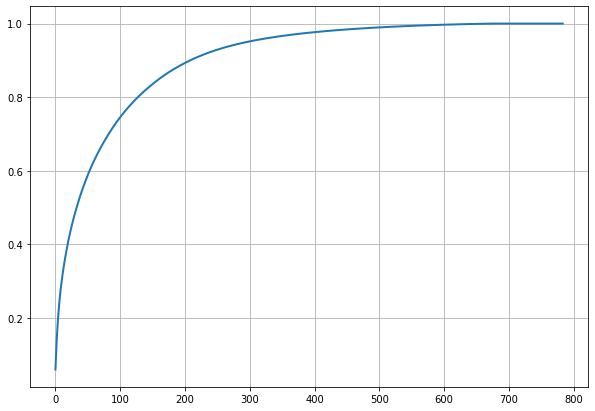

In [43]:
# Plottig the PCA

plt.figure(1,figsize=(10,7))
plt.plot(cum_var_explained,linewidth=2)
plt.grid()
plt.show()

From above you can see that if we take 200-dimensions, approx. 90% of variance is expalined.

Our intention with the princpal component analysis is to reduce the high-dimensional input to a low-dimensional input. Ultimately that low-dimensional input is intended for use in a model, since adding more components increases the cost and the accuracy.

**PLS UPVOTE IF YOU FOUND THE CONTENT HELPFUL :)**